# 3_analise.ipynb
Parte 3 do trabalho: aqui eu respondo as perguntas de negócio com consulta SQL,
faço uma tabela e um gráfico pra cada uma, e no final crio a camada Gold
(uma tabela que junta viagem + pagamento, agrupada por órgão).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

from config import DB_CONFIG

url_conexao = (
    f"mysql+mysqlconnector://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

banco = create_engine(url_conexao)

print("Conexão configurada com sucesso!")

Conexão configurada com sucesso!


## Criando a camada Gold
Aqui eu junto (JOIN) a tabela de viagem com a de pagamento e agrupo (GROUP BY)
por órgão, pra saber quanto cada órgão gastou no total.

In [3]:
# apago se já existir, pra poder rodar de novo sem dar erro
comando_apagar = "DROP TABLE IF EXISTS gold_custo_por_orgao;"

# cria a tabela gold já com o resultado do JOIN + GROUP BY
comando_criar_tabela = """
CREATE TABLE gold_custo_por_orgao AS
SELECT
    v.nome_orgao_superior AS orgao,
    COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
    ROUND(SUM(p.valor), 2) AS custo_total,
    ROUND(SUM(p.valor) / COUNT(DISTINCT v.id_viagem), 2) AS custo_medio_por_viagem
FROM silver_viagem v
JOIN silver_pagamento p ON p.id_viagem = v.id_viagem
GROUP BY v.nome_orgao_superior;
"""

# além da tabela, crio também uma VIEW (sempre fica atualizada sozinha)
comando_criar_view = """
CREATE OR REPLACE VIEW vw_gold_custo_por_orgao AS
SELECT
    v.nome_orgao_superior AS orgao,
    COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
    ROUND(SUM(p.valor), 2) AS custo_total,
    ROUND(SUM(p.valor) / COUNT(DISTINCT v.id_viagem), 2) AS custo_medio_por_viagem
FROM silver_viagem v
JOIN silver_pagamento p ON p.id_viagem = v.id_viagem
GROUP BY v.nome_orgao_superior;
"""

with banco.begin() as conexao:
    conexao.execute(text(comando_apagar))
    conexao.execute(text(comando_criar_tabela))
    conexao.execute(text(comando_criar_view))

print("Camada gold criada!")


Camada gold criada!


## Pergunta 1 - Os 5 órgãos com maior custo total

In [4]:
pergunta_1 = pd.read_sql("""
    SELECT orgao, custo_total
    FROM gold_custo_por_orgao
    ORDER BY custo_total DESC
    LIMIT 5
""", banco)

pergunta_1


,orgao,custo_total
0,Ministério da Justiça e Segurança Pública,4.888311e+08
1,Ministério da Defesa,1.565498e+08
2,Ministério da Educação,1.118974e+08
3,Ministério do Meio Ambiente e Mudança do Clima,5.012304e+07
4,Ministério da Previdência Social,4.065949e+07


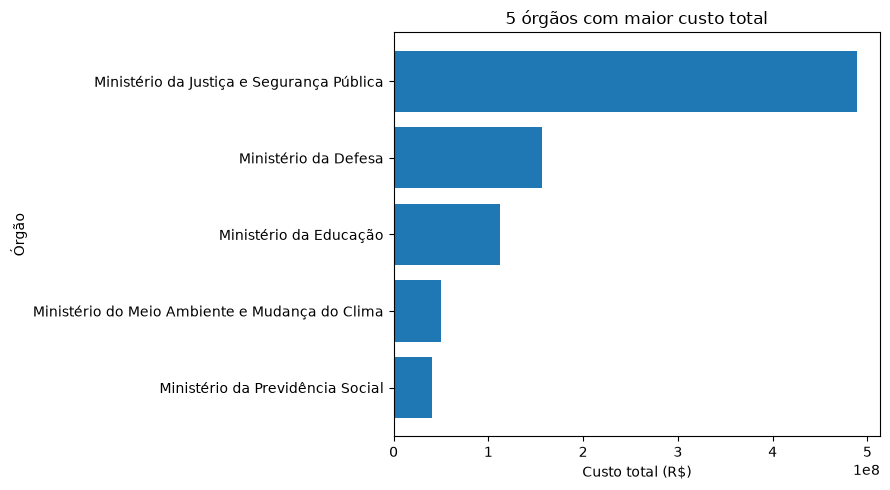

In [5]:
plt.figure(figsize=(9, 5))
plt.barh(pergunta_1["orgao"], pergunta_1["custo_total"])
plt.xlabel("Custo total (R$)")
plt.ylabel("Órgão")
plt.title("5 órgãos com maior custo total")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


*Repara que o órgão do topo dessa lista já responde também a pergunta "qual órgão pagou mais no total".*

## Pergunta 2 - Os 3 destinos com maior custo médio por viagem

In [6]:
pergunta_2 = pd.read_sql("""
    SELECT destinos, ROUND(AVG(valor_total), 2) AS custo_medio
    FROM silver_viagem
    WHERE destinos IS NOT NULL
    GROUP BY destinos
    HAVING COUNT(*) >= 3
    ORDER BY custo_medio DESC
    LIMIT 3
""", banco)

pergunta_2



,destinos,custo_medio
0,"Brasília/DF, Rio de Janeiro/RJ, Brasília/DF, B...",125976.81
1,"Brasília/DF, Barbacena/MG, Rio de Janeiro/RJ, ...",121814.17
2,"Brasília/DF, Belém/PA, Brasília/DF, Brasília/DF",116741.55


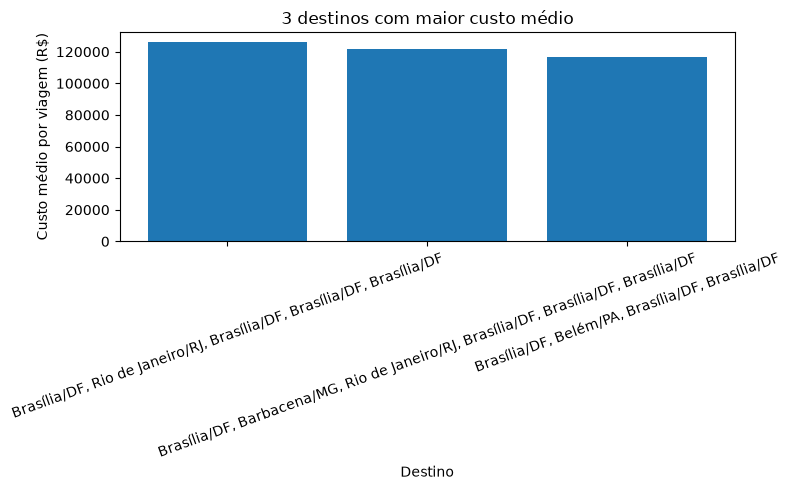

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(pergunta_2["destinos"], pergunta_2["custo_medio"])
plt.xlabel("Destino")
plt.ylabel("Custo médio por viagem (R$)")
plt.title("3 destinos com maior custo médio")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Pergunta 3 - A viagem de maior duração e o custo total dela

In [8]:
pergunta_3 = pd.read_sql("""
    SELECT id_viagem, nome_viajante, nome_orgao_superior, duracao_dias, valor_total
    FROM silver_viagem
    ORDER BY duracao_dias DESC
    LIMIT 1
""", banco)

pergunta_3


,id_viagem,nome_viajante,nome_orgao_superior,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,384,0.0


## Pergunta 4 - Tipo de pagamento com maior valor médio

In [9]:
pergunta_4 = pd.read_sql("""
    SELECT tipo_pagamento, ROUND(AVG(valor), 2) AS valor_medio
    FROM silver_pagamento
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
""", banco)

pergunta_4


,tipo_pagamento,valor_medio
0,DIÁRIAS,2104.10
1,PASSAGEM,1866.66
2,Serviço correlato: seguro,453.04
3,RESTITUIÇÃO,255.46


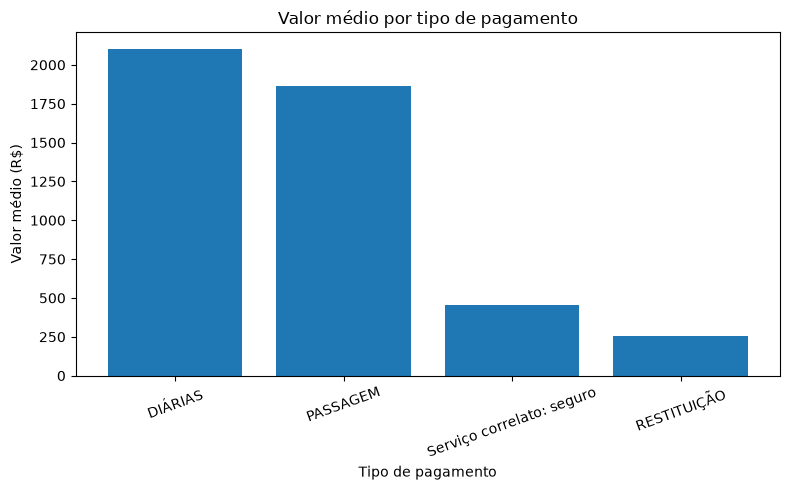

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(pergunta_4["tipo_pagamento"], pergunta_4["valor_medio"])
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio (R$)")
plt.title("Valor médio por tipo de pagamento")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Pergunta 5 - Meio de transporte mais usado nos trechos

In [11]:
pergunta_5 = pd.read_sql("""
    SELECT meio_transporte, COUNT(*) AS qtd_trechos
    FROM silver_trecho
    GROUP BY meio_transporte
    ORDER BY qtd_trechos DESC
""", banco)

pergunta_5


,meio_transporte,qtd_trechos
0,Veículo Oficial,356215
1,Aéreo,228413
2,Rodoviário,64453
3,Veículo Próprio,37250
4,Inválido,26527
5,Fluvial,8333
6,Ferroviário,826
7,Marítimo,481


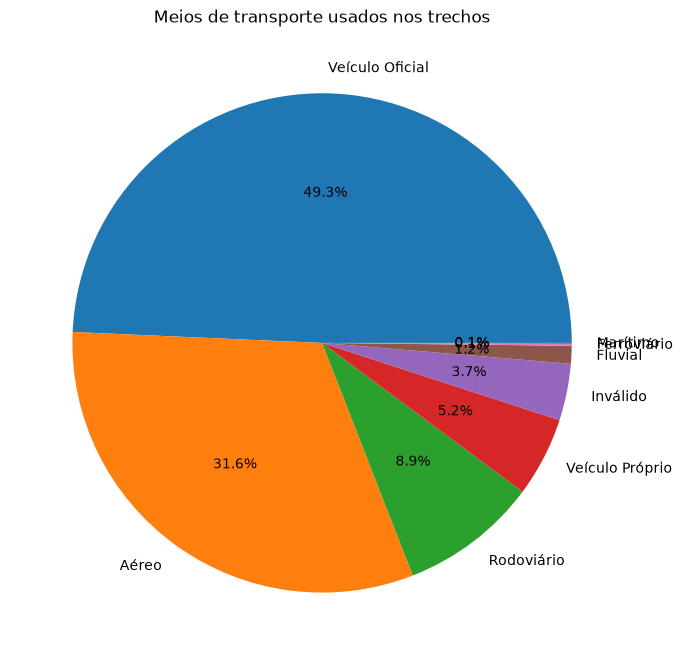

In [12]:
plt.figure(figsize=(7, 7))
plt.pie(pergunta_5["qtd_trechos"], labels=pergunta_5["meio_transporte"], autopct="%1.1f%%")
plt.title("Meios de transporte usados nos trechos")
plt.tight_layout()
plt.show()


## Pergunta 6 - UF de destino que mais aparece nos trechos

In [13]:
pergunta_6 = pd.read_sql("""
    SELECT destino_uf, COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE destino_uf IS NOT NULL
    GROUP BY destino_uf
    ORDER BY qtd_trechos DESC
    LIMIT 10
""", banco)

pergunta_6


,destino_uf,qtd_trechos
0,Distrito Federal,78539
1,São Paulo,74019
2,Minas Gerais,46181
3,Rio de Janeiro,43409
4,Paraná,39166
5,Pará,38760
6,Rio Grande do Sul,35884
7,Mato Grosso do Sul,29355
8,Pernambuco,27153
9,Amazonas,26184


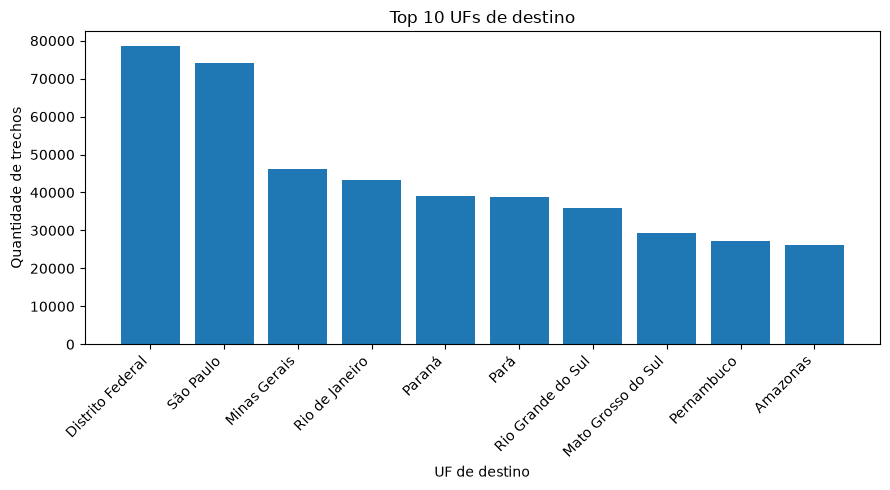

In [14]:
plt.figure(figsize=(9, 5))
plt.bar(pergunta_6["destino_uf"], pergunta_6["qtd_trechos"])
plt.xlabel("UF de destino")
plt.ylabel("Quantidade de trechos")
plt.title("Top 10 UFs de destino")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Minhas conclusões

A análise dos dados de viagens a serviço de 2025 permitiu identificar diferentes padrões relacionados aos gastos públicos, aos órgãos responsáveis pelas viagens, aos meios de transporte e aos destinos registrados na base.

Entre os órgãos analisados, o **Ministério da Justiça e Segurança Pública** apresentou o maior custo total, com aproximadamente **R$ 486,9 milhões** registrados. Esse resultado demonstra uma diferença significativa entre os gastos dos órgãos e permite identificar quais possuem maior participação nos custos das viagens.

Na análise dos meios de transporte, o **transporte aéreo** apresentou forte predominância, com **160.578 registros de passagens**, enquanto os transportes rodoviário e fluvial apresentaram quantidades significativamente menores.

Também foi identificada uma viagem com a maior duração registrada de **384 dias**, pertencente ao Ministério da Previdência Social, com valor total de **R$ 0,00**. Esse resultado chama atenção e demonstra a importância de analisar os dados não apenas para encontrar os maiores valores, mas também para identificar registros que podem precisar de uma verificação mais detalhada.

As demais análises permitiram comparar os destinos com maiores custos médios, os tipos de pagamento com maiores valores médios e as UFs mais frequentes como destino. Dessa forma, as consultas SQL, tabelas e gráficos facilitaram a interpretação de uma grande quantidade de registros.

De maneira geral, o projeto mostrou como o tratamento e a organização dos dados são fundamentais para gerar informações úteis. A utilização das camadas **RAW, SILVER e GOLD**, juntamente com SQL, Python e visualizações gráficas, permitiu transformar os dados brutos em informações mais estruturadas e fáceis de analisar.
